In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as opt
import sympy as sp

# Download Data & Data Inspection

In [24]:
df = pd.read_csv("HW2_Prob1_data.txt")
df

,# x y z
0,-1 -1 1
1,-1 1 1
2,1 1 1
3,1 -1 1
4,1 -1 1
...,...
995,1 1 1
996,1 1 1
997,1 -1 1
998,-1 -1 1


In [25]:
df["# x y z"] = df["# x y z"].str.strip()
df[["x", "y", "z"]] = df["# x y z"].str.split(expand=True).astype(float)
df.drop(columns=["# x y z"], inplace=True)
df.head()

,x,y,z
0,-1.0,-1.0,1.0
1,-1.0,1.0,1.0
2,1.0,1.0,1.0
3,1.0,-1.0,1.0
4,1.0,-1.0,1.0


# Direct Inversion Approach

In [26]:
sgx, sgy, sgz = df.x.mean(), df.y.mean(), df.z.mean()
varx, vary, varz = df.x.var(), df.y.var(), df.z.var()
print(f"SGX: {sgx:.6f}, SGY: {sgy:.6f}, SGZ: {sgz:.6f}")
print(f"\nSGX^2 + SGY^2 + SGZ^2: {sgx**2 + sgy**2 + sgz**2:.6f}")
print(f"\nVariance: {varx:.6f}")
print(f"Variance: {vary:.6f}")
print(f"Variance: {varz:.6f}")

SGX: 0.392000, SGY: -0.336000, SGZ: 0.876000

SGX^2 + SGY^2 + SGZ^2: 1.033936

Variance: 0.847183
Variance: 0.887992
Variance: 0.232857


Bloch Sphere Visualization

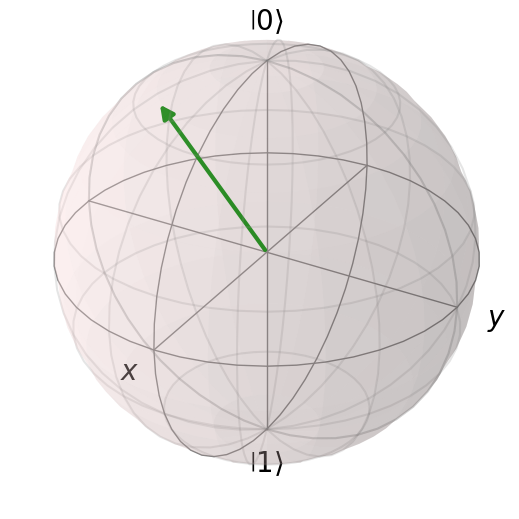

In [27]:
import qutip as qt
# calculating the state vector from the Bloch vector
rho0 = qt.Qobj(0.5 * (qt.qeye(2) + sgx*qt.sigmax() + sgy*qt.sigmay() + sgz*qt.sigmaz()))

# Plot on Bloch sphere
b = qt.Bloch()
b.add_states(rho0)
b.show()


# Log-Likelihood Approach

counting of shots

In [28]:
Nx_p = (df.x== 1).sum(); Nx_m = (df.x==-1).sum()
Ny_p = (df.y== 1).sum(); Ny_m = (df.y==-1).sum()
Nz_p = (df.z== 1).sum(); Nz_m = (df.z==-1).sum()
N = len(df)
print(f'Nx+={Nx_p}, Nx-={Nx_m}, Ny+={Ny_p}, Ny-={Ny_m}, Nz+={Nz_p}, Nz-={Nz_m}, N={N}')

Nx+=696, Nx-=304, Ny+=332, Ny-=668, Nz+=938, Nz-=62, N=1000


likelihood function and optimization

In [38]:
#Log-likehood function 
def log_likelihood(params):
    rx, ry, rz = params
    if rx**2 + ry**2 + rz**2 > 1:
        return 1e10  # enforce Bloch sphere constraint
    eps = 1e-15
    rx_term0 = (1 + sgx)/(1 + rx)
    ry_term0 = (1 + sgy)/(1 + ry)
    rz_term0 = (1 + sgz)/(1 + rz)

    rx_term1 = (1 - sgx)/(1 - rx)
    ry_term1 = (1 - sgy)/(1 - ry)
    rz_term1 = (1 - sgz)/(1 - rz)
    ll  = Nx_p*np.log(max(rx_term0, eps)) + Nx_m*np.log(max(rx_term1, eps))
    ll += Ny_p*np.log(max(ry_term0, eps)) + Ny_m*np.log(max(ry_term1, eps))
    ll += Nz_p*np.log(max(rz_term0, eps)) + Nz_m*np.log(max(rz_term1, eps))
    return ll

x0_guess, y0_guess, z0_guess = 0.5, 0.5, 0.5
initial_guess = [x0_guess, y0_guess, z0_guess]
result = opt.minimize(log_likelihood, initial_guess, method='Nelder-Mead')
estimated_params = result.x
print("Estimated Parameters:")
print(f"x0: {estimated_params[0]:.6f}, y0: {estimated_params[1]:.6f}, z0: {estimated_params[2]:.6f}")
r = np.sqrt(estimated_params[0]**2 + estimated_params[1]**2 + estimated_params[2]**2)
print(f"Estimated Bloch vector length: {r:.6f}")

Estimated Parameters:
x0: 0.396205, y0: -0.298210, z0: 0.868385
Estimated Bloch vector length: 1.000000


Plots of search space of the likelihood function in 2D

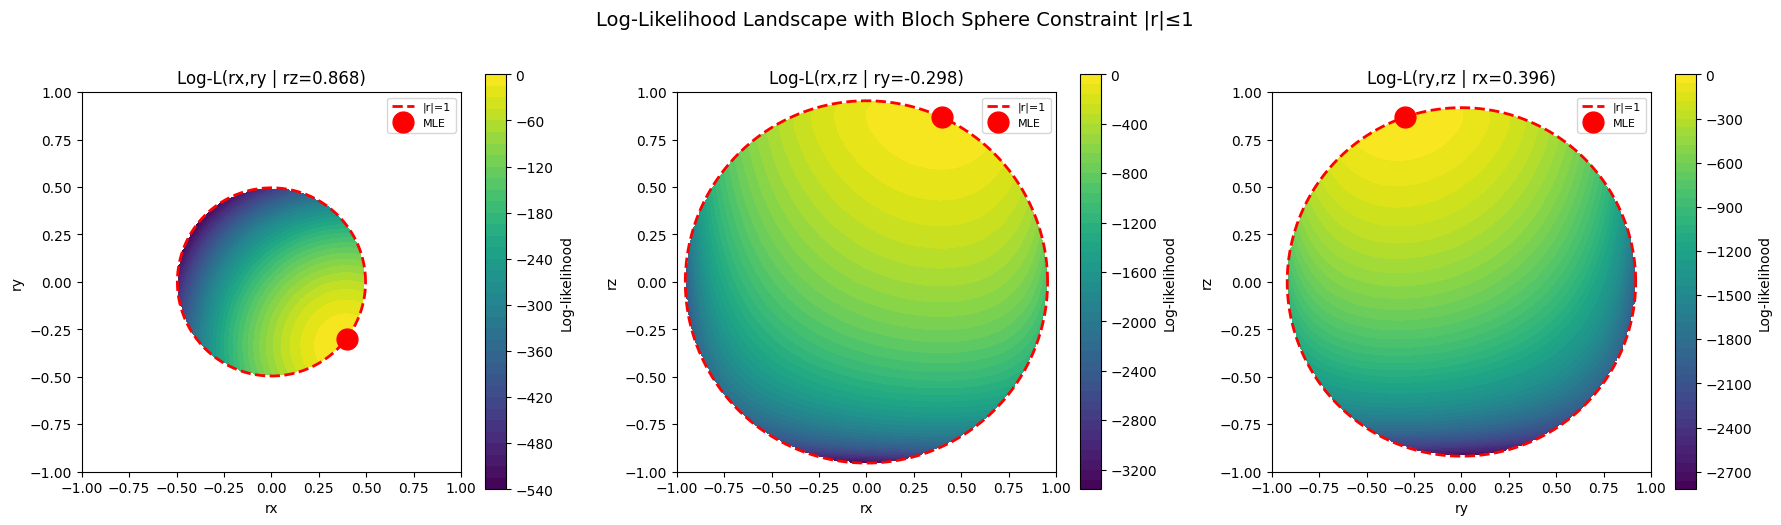

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grid_n = 200
theta = np.linspace(0, 2*np.pi, 200)
rx_mle, ry_mle, rz_mle = estimated_params
for idx, (a_label, b_label, fix_label, a_mle, b_mle, fix_mle) in enumerate([
    ('rx','ry','rz', rx_mle, ry_mle, rz_mle),
    ('rx','rz','ry', rx_mle, rz_mle, ry_mle),
    ('ry','rz','rx', ry_mle, rz_mle, rx_mle)]):
    a_range = np.linspace(-1, 1, grid_n)
    b_range = np.linspace(-1, 1, grid_n)
    A, B = np.meshgrid(a_range, b_range)
    LL = np.full_like(A, np.nan)
    for i in range(grid_n):
        for j in range(grid_n):
            a_, b_ = A[i,j], B[i,j]
            if a_**2 + b_**2 + fix_mle**2 <= 1:
                if idx == 0: params = [a_, b_, fix_mle]
                elif idx == 1: params = [a_, fix_mle, b_]
                else: params = [fix_mle, a_, b_]
                LL[i,j] = -log_likelihood(params)
    ax = axes[idx]
    c = ax.contourf(A, B, LL, levels=50, cmap='viridis')
    plt.colorbar(c, ax=ax, label='Log-likelihood')
    r_max = np.sqrt(max(1 - fix_mle**2, 0))
    ax.plot(r_max*np.cos(theta), r_max*np.sin(theta), 'r--', lw=2, label=f'|r|=1')
    ax.plot(a_mle, b_mle, 'ro', ms=15, label='MLE')
    ax.set_xlabel(a_label); ax.set_ylabel(b_label)
    ax.set_title(f'Log-L({a_label},{b_label} | {fix_label}={fix_mle:.3f})')
    ax.legend(fontsize=8); ax.set_aspect('equal')

plt.suptitle('Log-Likelihood Landscape with Bloch Sphere Constraint |r|≤1', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

comparison plot of the two method

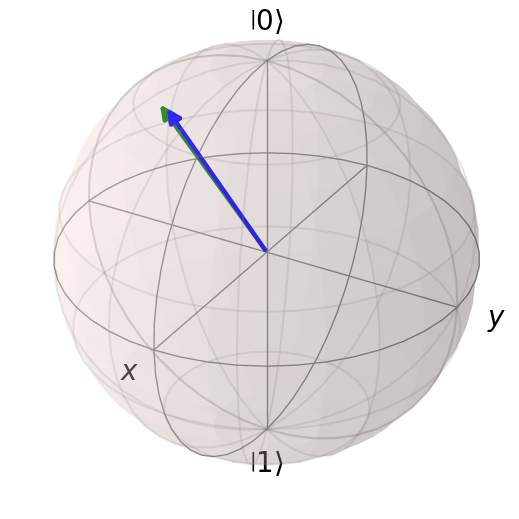

In [39]:
b.add_vectors(estimated_params)
b.show()

Rewrite each state vector into a quantum state form

In [32]:
def angles_to_state(theta, phi):
    # Construct using basis states
    return np.cos(theta/2) * qt.basis(2,0) + np.exp(1j*phi) * np.sin(theta/2) * qt.basis(2,1)

# Direct Inversion Method
bloch_vec0 = np.array([sgx, sgy, sgz])
theta0 = 2*np.arccos(sgz) if sgz <= 1 else print("Invalid Bloch vector: z component exceeds 1")
phi0 = np.arctan2(sgy, sgx)
psi0 = angles_to_state(theta0, phi0)

# Log-likelihood Maximization Method
bloch_vec_mle = estimated_params
theta_mle = 2*np.arccos(bloch_vec_mle[2]) if bloch_vec_mle[2] <= 1 else print("Invalid Bloch vector: z component exceeds 1")
phi_mle = np.arctan2(bloch_vec_mle[1], bloch_vec_mle[0])
psi_mle = angles_to_state(theta_mle, phi_mle)

print(f"Direct Inversion State: |psi0> = {psi0}")
display(psi0)
print(f"MLE State: |psi_mle> = {psi_mle}")
display(psi_mle)

inner  = (psi0.dag()@psi_mle)
fidelity = qt.metrics.fidelity(psi0, psi_mle)
traceD = qt.metrics.tracedist(psi0, psi_mle)
print(f"the innerproduct |<psi0|psi_mle>|2 = {abs(inner)**2}")
print(f"The fidelity F = {fidelity}")
print(f"The trace distance D = {traceD}")

Direct Inversion State: |psi0> = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.876     +0.j        ]
 [0.36619789-0.31388391j]]


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.876     +0.j        ]
 [0.36619789-0.31388391j]]

MLE State: |psi_mle> = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.86838492+0.j        ]
 [0.39620513-0.29820987j]]


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.86838492+0.j        ]
 [0.39620513-0.29820987j]]

the innerproduct |<psi0|psi_mle>|2 = 0.999026045699389
The fidelity F = 0.9995129042185444
The trace distance D = 0.031208240908626724


# Problem 2

Defining a set of density operator basis

In [33]:
# ansatz
I = sp.eye(2)
X = sp.Matrix([[0, 1], [1, 0]])
iY = sp.Matrix([[0, -1], [1, 0]])
Z = sp.Matrix([[1, 0], [0, -1]])
A = [I, X, iY, Z]

# density operator basis
rho0 = sp.Matrix([[1, 0], [0, 0]])
rho1 = sp.Matrix([[0, 1], [0, 0]])
rho2 = sp.Matrix([[0, 0], [1, 0]])
rho3 = sp.Matrix([[0, 0], [0, 1]])
Rho = [rho0, rho1, rho2, rho3]

The output density matrices

In [34]:
gamma = sp.symbols('gamma', real=True, positive=True)
rho0_new = sp.Matrix([[1, 0], [0, 0]])
rho1_new = sp.Matrix([[0, sp.sqrt(1 - gamma)], [0, 0]])
rho2_new = sp.Matrix([[0, 0], [sp.sqrt(1 - gamma), 0]])
rho3_new = sp.Matrix([[gamma, 0], [0, 1 - gamma]])
Rho_new = [rho0_new, rho1_new, rho2_new, rho3_new]

In [35]:
Lambda = sp.zeros(16, 1)
Beta = sp.zeros(16, 16)
for j in range(4):
    rho_out_vec = Rho_new[j].reshape(4, 1) # mapped outputs
    for m in range(4):
        for n in range(4):
            block = A[m] * Rho[j] * A[n].adjoint() # each beta element m,n being 4 x 4 block
            block_vec = block.reshape(4, 1)
            for k in range(4):
                Beta[j*4 + k, m*4 + n] = block_vec[k] 
    for k in range(4):
        Lambda[j*4 + k] = rho_out_vec[k] # remap the mapped output into lambda vector

chi_vec = Beta.solve(Lambda) # solve beta * chi = lambda, for chi (16, 1)
chi_matrix = chi_vec.reshape(4, 4) # redimension chi
display(sp.simplify(chi_matrix))


Matrix([
[-gamma/4 + sqrt(1 - gamma)/2 + 1/2,        0,        0,                            gamma/4],
[                                 0,  gamma/4, -gamma/4,                                  0],
[                                 0, -gamma/4,  gamma/4,                                  0],
[                           gamma/4,        0,        0, -gamma/4 - sqrt(1 - gamma)/2 + 1/2]])

Determine for the case of $\gamma = 0$, and $\gamma = 0.05$

In [36]:
chi0 = sp.simplify(chi_matrix.subs(gamma, 0))
display(chi0)

chi05 = sp.simplify(chi_matrix.subs(gamma, sp.Rational(1,20)))
display(chi05)

Matrix([
[1, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])

Matrix([
[sqrt(95)/20 + 39/80,     0,     0,                1/80],
[                  0,  1/80, -1/80,                   0],
[                  0, -1/80,  1/80,                   0],
[               1/80,     0,     0, 39/80 - sqrt(95)/20]])